In [5]:
from stormpy import export_to_drn
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from verimon.logger import setup_logging

setup_logging()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from verimon import loaders
from random import randrange
from math import sqrt


mc_sl_u_nxn = "../tests/snake_ladder/mc_u_nxn.pm"

n, ladders, snakes = loaders.random_snl_board(4**2)
# n, ladders, snakes = (25, {17: 19, 9: 15, 8: 15, 6: 10, 14: 21}, {23: 8, 22: 20, 8: 1, 18: 2, 12: 2})
print(n, ladders, snakes)

# Random snakes and ladders
# mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n, ladders, snakes)

milton_snakes = {98: 76, 95: 75, 93: 73, 87: 24, 64: 60, 62: 19, 55: 53, 49: 11, 47: 26, 16: 6}
milton_ladders = {1: 38, 4: 14, 9: 31, 28: 64, 40: 42, 36: 44, 51: 67, 71: 91, 80: 100}
mc, expr_man = loaders.load_snl_stormpy(mc_sl_u_nxn, n := 10**2, ladders:=milton_ladders, snakes:=milton_snakes)

16 {5: 11, 7: 13, 6: 10} {9: 6, 12: 1, 15: 12}


In [7]:
from stormvogel.mapping import stormpy_to_stormvogel
from stormvogel.show import show
import stormvogel

stormvogel.communication_server.enable_server = False

mc_sv = stormpy_to_stormvogel(mc)
if mc_sv is None:
    raise Exception("boom")
loaders._add_valuation_to_sv_labels(mc, mc_sv)
show(mc_sv)

Using matplotlib backend: module://matplotlib_inline.backend_inline


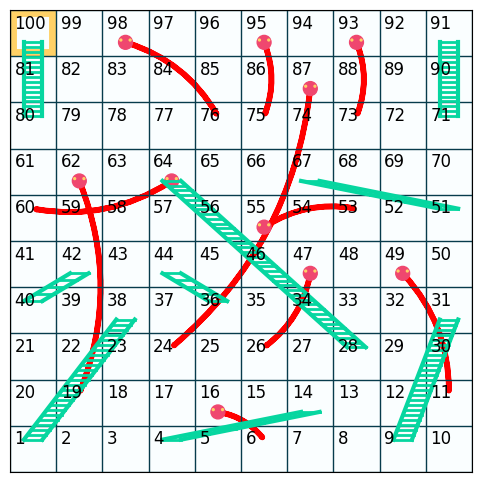

In [8]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

player_path = [(0, [])]

goal_squares = [next(int(l[5:-1]) for l in state.labels if l.startswith("[pos")) 
                for state in mc_sv.states.values() 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())

In [ ]:
from aalpy import run_Lstar, Dfa
from verimon.MonitorLearning import FilteringSUL, VerimonEqOracle

setup_logging()


threshold = 0.4
fp_slack = 0.3
fn_slack = 0.05
horizon = 14
relative_error = 0.1
spec = 'P>0.5 [F<3 "good" ]'

alphabet = ["init", "normal", "snake", "ladder"]

filtering_sul = FilteringSUL(
    mc, 
    "init", 
    alphabet, 
    spec, 
    threshold, 
    horizon
)
eq_oracle = VerimonEqOracle(
    alphabet,
    filtering_sul,
    mc,
    threshold,
    fp_slack,
    fn_slack,
    horizon,
    spec,
    'good',
    relative_error,
    False,
    expr_man
)
learned_monitor: Dfa = run_Lstar(
    alphabet,
    filtering_sul,
    eq_oracle,
    automaton_type="dfa",
    print_level=2,
) #type: ignore

DEBUG:2024-11-19 14:43:14,464 - (0.00s) - MonitorLearning.py - Filtering SUL is using the following risk function: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.08333333333333333, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 1.0, 0.0, 0.0, 0.08333333333333333, 0.0, 0.25, 0.0, 0.25, 0.25, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.027777777777777776, 0.0, 0.25, 0.027777777777777776, 0.05555555555555555] 
Hypothesis 1: 1 states.
Visualization started in the background thread.
DEBUG:2024-11-19 14:43:14,466 - (0.00s) - MonitorLearning.py - Finding false negative probability 
Model saved to models/mod

INFO:paynt.quotient.pomdp:constructed POMDP having 16 observations.


2024-11-19 14:43:14,545 - pomdp.py - constructed POMDP having 16 observations.
2024-11-19 14:43:14,545 - pomdp.py - constructed POMDP having 16 observations.


DEBUG:paynt.quotient.pomdp:unfolding 1-FSC template into POMDP...


2024-11-19 14:43:14,546 - pomdp.py - unfolding 1-FSC template into POMDP...
2024-11-19 14:43:14,546 - pomdp.py - unfolding 1-FSC template into POMDP...


DEBUG:paynt.quotient.pomdp:constructed quotient MDP having 772 states and 2900 actions.


2024-11-19 14:43:14,549 - pomdp.py - constructed quotient MDP having 772 states and 2900 actions.
2024-11-19 14:43:14,549 - pomdp.py - constructed quotient MDP having 772 states and 2900 actions.


INFO:paynt.synthesizer.statistic:synthesis initiated, design space: 1e8


2024-11-19 14:43:14,551 - statistic.py - synthesis initiated, design space: 1e8
2024-11-19 14:43:14,551 - statistic.py - synthesis initiated, design space: 1e8
ERROR (SubsystemBuilder.cpp:115): Expected that in each state, at least one action is selected. Got a deadlock state instead. (violated at 764)


RuntimeError: InvalidOperationException: Expected that in each state, at least one action is selected. Got a deadlock state instead. (violated at 764)

In [ ]:
from verimon.MonitorLearning import aalpy_dfa_to_stormvogel
from verimon.transformations import simulator_unroll, prune_monitor
from verimon.algs import complement_model

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
# show(mon_cycl)
# complement_model(mon_cycl, "accepting")
mon = simulator_unroll(mon_cycl, horizon)
prune_monitor(mon)
print(len(mon.states))
show(mon)

244


In [ ]:
from verimon.MonitorLearning import aalpy_dfa_to_stormvogel
from verimon.verify import *

mon_cycl = aalpy_dfa_to_stormvogel(learned_monitor)
export_to_drn(stormvogel_to_stormpy(mon_cycl), "monitor.drn")
result_goal, trace, assignment, product = false_positive(mc, mon_cycl, horizon, expr_man, options = {"good_spec": spec})

Write to file monitor.drn.
DEBUG:2024-11-18 10:33:55,699 - (12.17s) - verify.py - Building model 
DEBUG:2024-11-18 10:33:55,773 - (0.07s) - verify.py - Unrolling done 
INFO:2024-11-18 10:33:55,783 - (0.01s) - generator.py - New good states become: [81, 93] 
DEBUG:2024-11-18 10:33:55,783 - (0.00s) - verify.py - Apply spec done 
DEBUG:2024-11-18 10:33:56,306 - (0.52s) - verify.py - creating product done 
DEBUG:2024-11-18 10:33:56,307 - (0.00s) - verify.py - Creating trace 


INFO:paynt.quotient.pomdp:constructed POMDP having 21 observations.


2024-11-18 10:33:56,401 - pomdp.py - constructed POMDP having 21 observations.


DEBUG:paynt.quotient.pomdp:unfolding 1-FSC template into POMDP...


2024-11-18 10:33:56,403 - pomdp.py - unfolding 1-FSC template into POMDP...


...

2024-11-18 10:35:41,550 - synthesizer.py - printing synthesized assignment below:


INFO:paynt.synthesizer.synthesizer:A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=init, A(13,0)=normal, A(14,0)=init, A(15,0)=normal, A(16,0)=init, A(17,0)=ladder, A(18,0)=init, A(19,0)=init, A(20,0)=end


2024-11-18 10:35:41,551 - synthesizer.py - A(2,0)=ladder, A(3,0)=normal, A(4,0)=ladder, A(5,0)=normal, A(6,0)=normal, A(7,0)=normal, A(8,0)=normal, A(9,0)=normal, A(10,0)=normal, A(11,0)=normal, A(12,0)=init, A(13,0)=normal, A(14,0)=init, A(15,0)=normal, A(16,0)=init, A(17,0)=ladder, A(18,0)=init, A(19,0)=init, A(20,0)=end


INFO:paynt.synthesizer.synthesizer:double-checking specification satisfiability:  : 0.5003443123639507


2024-11-18 10:35:41,553 - synthesizer.py - double-checking specification satisfiability:  : 0.5003443123639507
INFO:2024-11-18 10:35:41,553 - (105.25s) - generator.py - --------------------
Synthesis summary:
optimality objective: Pmax=? [F "stop"] [eps = 0.1]

method: AR, synthesis time: 105.13 s
number of holes: 19, family size: 1e11, quotient: 5160 states / 20759 actions
explored: 100 %
MDP stats: avg MDP size: 370, iterations: 3853

feasible: yes
--------------------
 
INFO:2024-11-18 10:35:41,580 - (0.03s) - verify.py - Found trace: ['ladder', 'normal', 'ladder', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'normal', 'ladder'] 
INFO:2024-11-18 10:35:41,584 - (0.00s) - verify.py - Goal probability counterexample: 0.43183831083906804 


Using matplotlib backend: module://matplotlib_inline.backend_inline
INFO:2024-11-18 11:34:10,329 - (3499.53s) - generator.py - s2, obs=2, labels=init 


INFO:2024-11-18 11:34:34,489 - (24.16s) - generator.py - --[2, ladder]-->	s7, val={_mc21: 1,_mon20: 3,pos: 1}, labels=
--[3, normal]-->	s18, val={_mc21: 7,_mon20: 9,pos: 38}, labels=
--[4, ladder]-->	s41, val={_mc21: 15,_mon20: 19,pos: 40}, labels=
--[5, normal]-->	s91, val={_mc21: 17,_mon20: 34,pos: 42}, labels=
--[6, normal]-->	s180, val={_mc21: 30,_mon20: 56,pos: 46}, labels=
--[7, normal]-->	s325, val={_mc21: 48,_mon20: 90,pos: 52}, labels=
--[8, normal]-->	s529, val={_mc21: 50,_mon20: 137,pos: 54}, labels=
--[9, normal]-->	s773, val={_mc21: 59,_mon20: 192,pos: 58}, labels=
--[10, normal]-->	s1145, val={_mc21: 62,_mon20: 259,pos: 61}, labels=
--[11, normal]-->	s1707, val={_mc21: 71,_mon20: 344,pos: 63}, labels=
--[13, normal]-->	s2523, val={_mc21: 66,_mon20: 452,pos: 69}, labels=
--[15, normal]-->	s3454, val={_mc21: 74,_mon20: 567,pos: 74}, labels=
--[17, ladder]-->	s4791, val={_mc21: 81,_mon20: 719,pos: 80}, labels=
--[20, end]-->	s0, val={_mc21: -1,_mon20: -1,pos: -1}, labels=goa

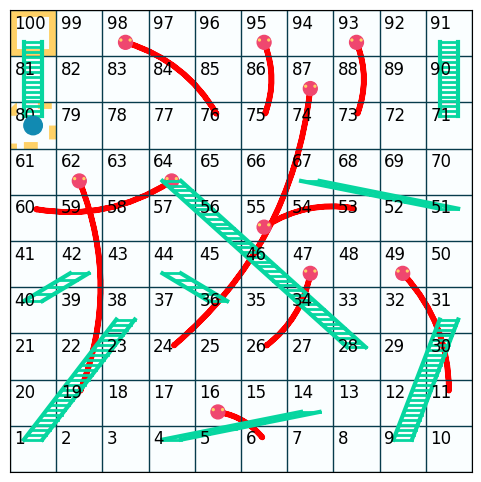

In [ ]:
%matplotlib
from verimon.draw import animate_player_movement
import math
from IPython.display import HTML

# player_path = [(0, [])]
poss = product.simulate_paynt_assignment(assignment, 100000)
player_path = poss

goal_squares = [int(str(state.valuations)[5:-1]) 
                for state in product.mc.states 
                if "good" in state.labels]

animation = animate_player_movement(int(math.sqrt(n)), snakes, ladders, goal_squares, player_path)
HTML(animation.to_jshtml())